# Vector Quantized VAE (VQ-VAE)

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import numpy as np

from tqdm import tqdm
from torchvision.utils import save_image, make_grid

from torchvision.datasets import CIFAR10
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torch.optim import Adam

import matplotlib.pyplot as plt

In [5]:
dataset_path = './datasets'
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


batch_size = 128
img_size = (32, 32)
input_dim = 3
hidden_dim = 512
latent_dim = 16
n_embeddings= 512
output_dim = 3
commitment_beta = 0.25

lr = 2e-4
epochs = 50
print_step = 50

## Step1. Load Datasets

In [6]:
mnist_transform = transforms.Compose([
        transforms.ToTensor(),
])

kwargs = {'num_workers': 1, 'pin_memory': True} 

train_dataset = CIFAR10(dataset_path, transform=mnist_transform, train=True, download=True)
test_dataset  = CIFAR10(dataset_path, transform=mnist_transform, train=False, download=True)

train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True, **kwargs)
test_loader  = DataLoader(dataset=test_dataset,  batch_size=batch_size, shuffle=False,  **kwargs)

## Step2: Define Model

### Core difference between VAE and VQ-VAE

VAE basically has 4 essential elements here:

1. Continuous latent
2. Gaussian $q_{\phi}(\mathbf{z} | \mathbf{x})$ with sampling
3. Pre-defined $p_{\theta}(\mathbf{z})$
4. loss function: $-\mathbb{E}_{q_{\phi}(\mathbf{z} | \mathbf{x})} [\log p_{\theta}(\mathbf{x} | \mathbf{z})] + D_{KL}(q_{\phi}(\mathbf{z} | \mathbf{x}) || p(\mathbf{z}))$

VQVAE makes changes to all 4 elements.

#### Discrete Latent

The encoded vectors $\mathbf{Z_e}(\mathbf{x})$ get replaced by the nearest embedding vectors from a codebook $\mathbf{e}_k \in \mathbb{R}^{K \times D}$, where $K$ is the number of embeddings and $D$ is the dimensionality of each embedding vector. $\mathbf{z}_q = \mathbf{e}_k$ then feeds to the decoder (q meaning quantized).

#### Deterministic $q_{\phi}(\mathbf{z} | \mathbf{x})$

Since VQVAE looks for the nearest embedding vector, this process is deterministic, the posterior becomes:

$$q(\mathbf{z}_q = \mathbf{e}_k \mid \mathbf{x}) = 
\begin{cases} 
1 & \text{for } k = \operatorname*{argmin}_j \| z_e(x) - e_j \|_2 \\ 
0 & \text{otherwise}
\end{cases}$$

#### Learned Prior $p(\mathbf{z})$

The prior is initially defined as a uniform distribution over the codebook vectors:

$$p(\mathbf{z}_q = \mathbf{e}_k) = \frac{1}{K}$$

While training VQ-VAE, a more complex prior which approach the true prior can be learned. The author of VQVAE suggested using a secondary model (e.g., PixelCNN) to learn a more complex prior. Also Transformers can be used here.

#### Loss Function

Since the initial prior is uniform and posterior is deterministic, the KL divergence becomes a constant:

$$D_{KL} (q(\mathbf{z}_q \mid \mathbf{x}) || p(\mathbf{z}_q)) = \sum_k q(\mathbf{z}_q \mid \mathbf{x}) \log (\frac{q(\mathbf{z}_q \mid \mathbf{x})}{p(\mathbf{z}_q)}) = \log (\frac{1}{\frac{1}{K}}) = \log K $$

So KL term is not feasible. Even the learned prior may not be uniform, the deterministic posterior will make KL term very hard to optimize. So VQVAE drops this term but keep the reconstruction loss.

However, since the quantization operation is non-differentiable, the gradients from the decoder cannot propagate back to the encoder. To address this, VQVAE uses a technique called "straight-through estimator" (by Bengio et al., 2013) to copy the gradients from the decoder input to the encoder output:

$$ \nabla_{z_e} L \approx \nabla_{z_q} L $$

This works well when $\mathbf{z}_e \approx \mathbf{z}_q$.

Now the gradient backpropagation works, but it only updates parameters in the encoder and decoder. The notebook vectors is initially randomized and does not contain any useful information. So we need to update the codebook vectors by designing another loss term, called the "codebook loss":

$$ L_{codebook} = \| \text{sg}[z_e(x)] - e \|_2^2 $$

where $\text{sg}[\cdot]$ is the stop-gradient operator that prevents gradients from flowing into its argument. This term means to penalize the distance between the encoder output and notebook vectors, so that $\mathbf{z}_e \approx e_k = \mathbf{z}_q$. It should also be noted that only a subset of notebook vectors get updated in each iteration, i.e., the ones that are closest to the encoder outputs, so this loss term is sparse.

The combination of reconstruction loss and codebook loss works not very well in practice. Some penomenon is observed:

1. The encoder vectors fluctuate between notebook vectors, especially when the former updates quicklier than the latter. This leads to instability in training and redundancy between codewords.
2. The encoder vectors may grow unboundedly large, and the notebook vectors will follow them. This also leads to instable training.

To address both these issues, VQVAE introduces "commitment loss" to penalize the encoders:

$$ L_{commitment} = \| z_e(x) - \text{sg}[e] \|_2^2 $$

The final loss function then becomes:

$$ L = -\log p(\mathbf{x} | \mathbf{z}_q) + \| \text{sg}[z_e(x)] - e \|_2^2 + \beta \| z_e(x) - \text{sg}[e] \|_2^2 $$

where $\beta$ is a hyperparameter to balance the commitment loss.

### Why Discrete Latent?

1. Discrete representations are natural representations (speech, text, etc.)
2. Data compression: discrete latent can lead to higher compression rate

In [7]:
class Encoder(nn.Module):
    
    def __init__(self, input_dim, hidden_dim, output_dim, kernel_size=(4, 4, 3, 1), stride=2):
        super(Encoder, self).__init__()
        
        kernel_1, kernel_2, kernel_3, kernel_4 = kernel_size
        
        self.strided_conv_1 = nn.Conv2d(input_dim, hidden_dim, kernel_1, stride, padding=1)
        self.strided_conv_2 = nn.Conv2d(hidden_dim, hidden_dim, kernel_2, stride, padding=1)
        
        self.residual_conv_1 = nn.Conv2d(hidden_dim, hidden_dim, kernel_3, padding=1)
        self.residual_conv_2 = nn.Conv2d(hidden_dim, hidden_dim, kernel_4, padding=0)
        
        self.proj = nn.Conv2d(hidden_dim, output_dim, kernel_size=1)
        
    def forward(self, x):
        
        x = self.strided_conv_1(x)
        x = self.strided_conv_2(x)
        
        x = F.relu(x)
        y = self.residual_conv_1(x)
        y = y+x
        
        x = F.relu(y)
        y = self.residual_conv_2(x)
        y = y+x
        
        y = self.proj(y)
        return y

### Updates of Codewords

In practice if updaing codewords through gradients, VQVAE may suffer from codebook collapse, where only a small subset of codewords get used while others are never updated. Hence the author proposed an alternative way to update codewords through Exponential Moving Average (EMA).

First compute the cluster size for each codeword $\mathbf{e}_k$ using historical assignments:

$$ N_k^{(t)} = \gamma N_k^{(t-1)} + (1 - \gamma) n_k^{(t)} $$

Then use Laplace smoothing to avoid zero counts: (Smoothed cluster size)

$$ N_k^{(t)} \leftarrow \frac{N_k^{(t)} + \epsilon}{\sum_j N_j^{(t)} + \epsilon} · \sum_j N_j^{(t)}$$

$$ m_k^{(t)} = \gamma m_k^{(t-1)} + (1 - \gamma) \sum_{i=1}^{n_k^{(t)}} z_{i}^{(t)} $$

$$ e_k^{(t)} = \frac{m_k^{(t)}}{N_k^{(t)}} $$

where $n_k^{(t)}$ is the number of encoder outputs assigned to codeword $e_k$ at iteration $t$, and $z_i^{(t)}$ are those encoder outputs. $\gamma$ is the decay rate for EMA.

**Caution**: The following implementation uses both gradient updates and EMA updates for codewords. In practice, EMA updates alone work better. In this case, the codebook loss term should be removed from the loss function.

In [ ]:
class VQEmbeddingEMA(nn.Module):
    def __init__(self, n_embeddings, embedding_dim, commitment_cost=0.25, decay=0.999, epsilon=1e-5):
        super(VQEmbeddingEMA, self).__init__()
        self.commitment_cost = commitment_cost
        self.decay = decay
        self.epsilon = epsilon

        init_bound = 1 / n_embeddings
        embedding = torch.Tensor(n_embeddings, embedding_dim)
        embedding.uniform_(-init_bound, init_bound)
        self.register_buffer('embedding', embedding)
        self.register_buffer('ema_count', torch.zeros(n_embeddings))
        self.register_buffer('ema_weight', self.embedding.clone())

    def encode(self, x):
        M, D = self.embedding.size()
        x_flat = x.view(-1, D)

        distances = torch.cdist(x_flat, self.embedding, p=2) ** 2
        
        indices = torch.argmin(distances, dim=-1)
        quantized = F.embedding(indices, self.embedding)
        quantized = quantized.view_as(x)
        return quantized, indices.view(x.size(0), -1)
    
    # def retrieve_random_codebook(self, random_indices):
    #     quantized = F.embedding(random_indices, self.embedding)
    #     quantized = quantized.transpose(1, 3)
    #     return quantized
    
    def forward(self, x):
        M, D = self.embedding.size()
        x_flat = x.detach().view(-1, D)

        distances = torch.cdist(x_flat, self.embedding, p=2) ** 2
        indices = torch.argmin(distances, dim=-1)
        encodings = F.one_hot(indices, M).float()
        quantized = F.embedding(indices, self.embedding)
        quantized = quantized.view_as(x)

        if self.training:
            self.ema_count = self.ema_count * self.decay + (1 - self.decay) * torch.sum(encodings, dim=0)
            n = torch.sum(self.ema_count)
            self.ema_count = (self.ema_count + self.epsilon) / (n + M * self.epsilon) * n

            dw = torch.matmul(encodings.t(), x_flat)
            self.ema_weight = self.ema_weight * self.decay + (1 - self.decay) * dw
            self.embedding = self.ema_weight / self.ema_count.unsqueeze(-1)

        codebook_loss = F.mse_loss(x.detach(), quantized)
        e_latent_loss = F.mse_loss(x, quantized.detach())
        commitment_loss = self.commitment_cost * e_latent_loss

        # straight through!
        quantized = x + (quantized - x).detach()
        
        # average probabilities for each codewords
        avg_probs = torch.mean(encodings, dim=0)
        perplexity = torch.exp(-torch.sum(avg_probs * torch.log(avg_probs + 1e-10)))

        return quantized, commitment_loss, codebook_loss, perplexity

In [9]:
class Decoder(nn.Module):
    
    def __init__(self, input_dim, hidden_dim, output_dim, kernel_sizes=(1, 3, 2, 2), stride=2):
        super(Decoder, self).__init__()
        
        kernel_1, kernel_2, kernel_3, kernel_4 = kernel_sizes
        
        self.in_proj = nn.Conv2d(input_dim, hidden_dim, kernel_size=1)
        
        self.residual_conv_1 = nn.Conv2d(hidden_dim, hidden_dim, kernel_1, padding=0)
        self.residual_conv_2 = nn.Conv2d(hidden_dim, hidden_dim, kernel_2, padding=1)
        
        self.strided_t_conv_1 = nn.ConvTranspose2d(hidden_dim, hidden_dim, kernel_3, stride, padding=0)
        self.strided_t_conv_2 = nn.ConvTranspose2d(hidden_dim, output_dim, kernel_4, stride, padding=0)
        
    def forward(self, x):

        x = self.in_proj(x)
        
        y = self.residual_conv_1(x)
        y = y+x
        x = F.relu(y)
        
        y = self.residual_conv_2(x)
        y = y+x
        y = F.relu(y)
        
        y = self.strided_t_conv_1(y)
        y = self.strided_t_conv_2(y)
        
        return y

In [10]:
class Model(nn.Module):
    def __init__(self, Encoder, Codebook, Decoder):
        super(Model, self).__init__()
        self.encoder = Encoder
        self.codebook = Codebook
        self.decoder = Decoder
                
    def forward(self, x):
        z = self.encoder(x)
        z_quantized, commitment_loss, codebook_loss, perplexity = self.codebook(z)
        x_hat = self.decoder(z_quantized)
        
        return x_hat, commitment_loss, codebook_loss, perplexity

In [11]:
encoder = Encoder(input_dim=input_dim, hidden_dim=hidden_dim, output_dim=latent_dim)
codebook = VQEmbeddingEMA(n_embeddings=n_embeddings, embedding_dim=latent_dim)
decoder = Decoder(input_dim=latent_dim, hidden_dim=hidden_dim, output_dim=output_dim)

model = Model(Encoder=encoder, Codebook=codebook, Decoder=decoder).to(DEVICE)

## Step3: Define Loss Function and Optimizer

In [12]:
mse_loss = nn.MSELoss()

optimizer = Adam(model.parameters(), lr=lr)

## Step4: Training Loop

In [13]:
print("Start training VQ-VAE...")
model.train()

for epoch in range(epochs):
    overall_loss = 0
    for batch_idx, (x, _) in enumerate(train_loader):
        x = x.to(DEVICE)

        optimizer.zero_grad()

        x_hat, commitment_loss, codebook_loss, perplexity = model(x)
        recon_loss = mse_loss(x_hat, x)
        
        loss =  recon_loss + commitment_loss * commitment_beta + codebook_loss
                
        loss.backward()
        optimizer.step()
        
        if batch_idx % print_step ==0: 
            print("epoch:", epoch + 1, "(", batch_idx + 1, ") recon_loss:", recon_loss.item(), " perplexity: ", perplexity.item(), 
              " commit_loss: ", commitment_loss.item(), "\n\t codebook loss: ", codebook_loss.item(), " total_loss: ", loss.item(), "\n")
    
print("Finish!!")

Start training VQ-VAE...


epoch: 1 ( 1 ) recon_loss: 0.25039374828338623  perplexity:  26.5257568359375  commit_loss:  0.002406428102403879 
	 codebook loss:  0.009625712409615517  total_loss:  0.2606210708618164 

epoch: 1 ( 51 ) recon_loss: 0.023803114891052246  perplexity:  158.64492797851562  commit_loss:  0.039116982370615005 
	 codebook loss:  0.15646792948246002  total_loss:  0.19005028903484344 

epoch: 1 ( 101 ) recon_loss: 0.01593155227601528  perplexity:  204.42572021484375  commit_loss:  0.02852736786007881 
	 codebook loss:  0.11410947144031525  total_loss:  0.1371728628873825 

epoch: 1 ( 151 ) recon_loss: 0.01270768791437149  perplexity:  270.85162353515625  commit_loss:  0.026956070214509964 
	 codebook loss:  0.10782428085803986  total_loss:  0.12727098166942596 

epoch: 1 ( 201 ) recon_loss: 0.011252827942371368  perplexity:  306.064208984375  commit_loss:  0.027208644896745682 
	 codebook loss:  0.10883457958698273  total_loss:  0.12688957154750824 

epoch: 1 ( 251 ) recon_loss: 0.00975867547

## Step5: Evaluate the Model

In [14]:
def draw_sample_image(x, postfix):
  
    plt.figure(figsize=(8,8))
    plt.axis("off")
    plt.title("Visualization of {}".format(postfix))
    plt.imshow(np.transpose(make_grid(x.detach().cpu(), padding=2, normalize=True), (1, 2, 0)))

In [15]:
model.eval()

with torch.no_grad():

    for batch_idx, (x, _) in enumerate(tqdm(test_loader)):

        x = x.to(DEVICE)
        x_hat, commitment_loss, codebook_loss, perplexity = model(x)
 
        print("perplexity: ", perplexity.item(),"commit_loss: ", commitment_loss.item(), "  codebook loss: ", codebook_loss.item())
        break

  0%|          | 0/79 [00:00<?, ?it/s]

  0%|          | 0/79 [00:00<?, ?it/s]

perplexity:  409.31298828125 commit_loss:  0.020979035645723343   codebook loss:  0.08391614258289337


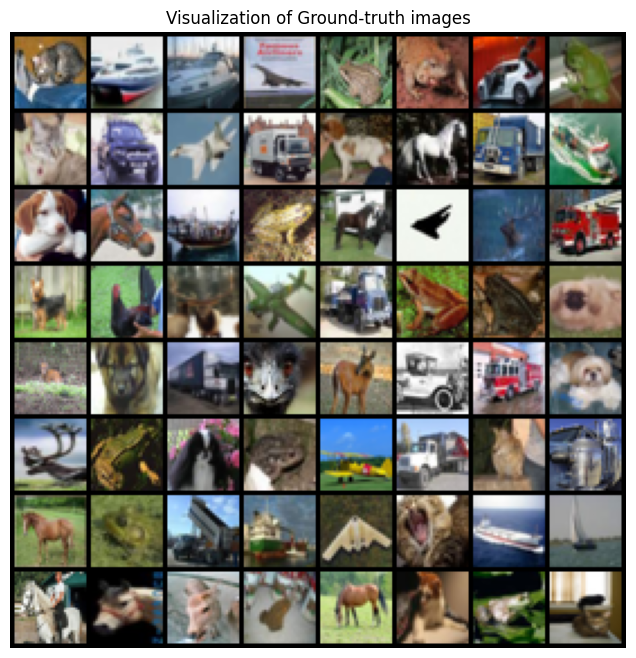

In [16]:
draw_sample_image(x[:batch_size//2], "Ground-truth images")

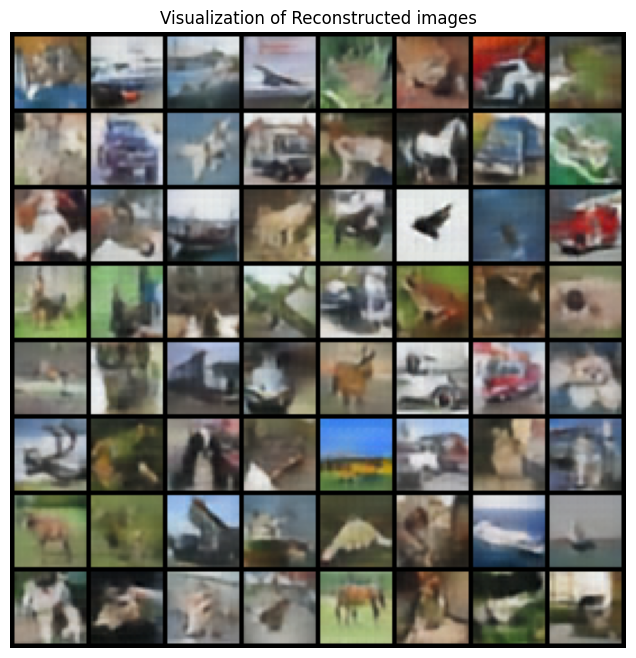

In [17]:
draw_sample_image(x_hat[:batch_size//2], "Reconstructed images")